## **Task 1. Data analysis**
**Points: 2**

**Make a thorough analysis of the data. Some possible questions to answer include (but is not limited to):**
• What patterns exist within the individual series?
• What relationships exist between the different series?
• Can the series be grouped? If so, indicate which groups you believe exist.

<br>
What other questions can you ask and answer? Extract as much information as you can and keep a critical mindset. It may be relevant to consider the returns of the price series, i.e., the change in price from one day to the next relative to the price itself (or alternatively the log-returns). While it is possible that the absolute price levels also contain useful information, in this case, it is probably a good approach to primarily work with returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time_series_analysis.utils import hello


In [2]:
df = pd.read_csv('../data/spiff_data-2.csv')
df

,Unnamed: 0,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
0,0,1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
1,1,2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
2,2,3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
3,3,4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
4,4,5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026
...,...,...,...,...,...,...,...,...,...
5451,5451,5452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5452,5452,5453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5453,5453,5454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5454,5454,5455,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
time_col = df.columns[1]

price_col = df.columns[2:]

returns = df[price_col].pct_change(fill_method=None)
display(returns.head(11))


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.005682,0.017458,-0.010743,0.001951,0.009275,0.000967,0.003279
2,-0.003390,-0.001204,0.001303,0.013856,-0.005744,-0.000644,0.013480
3,-0.001984,-0.005726,-0.009544,0.002442,-0.014443,0.000966,-0.004837
4,-0.005112,0.003334,0.001752,0.001099,0.004689,0.001073,0.004455
5,0.003426,0.011480,0.004373,-0.004086,0.000000,0.001393,-0.004032
6,0.001138,-0.002389,-0.005660,0.013369,-0.015169,-0.000428,-0.000810
7,0.000000,0.011078,0.000000,0.021392,0.015995,0.000000,-0.011345
8,0.001137,-0.007995,-0.030648,-0.008911,-0.006997,0.003211,-0.000410
9,0.003974,-0.004776,-0.012647,0.003531,0.000000,0.001067,0.001230


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
count,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000
mean,0.115672,0.205535,0.300274,0.150914,0.368342,0.179700,0.090150
std,3.842318,7.011706,10.141819,5.067705,12.447754,5.939157,3.037513
min,-0.993735,-0.997146,-0.997930,-0.995460,-0.998276,-0.996004,-0.992594
25%,-0.001999,-0.006593,-0.006523,-0.009935,-0.007493,-0.001753,-0.006752
50%,0.000000,0.000538,0.000462,0.000165,0.000000,0.000091,0.000000
75%,0.002446,0.007508,0.007533,0.010392,0.007845,0.002192,0.007076
max,157.332680,352.302407,484.940203,214.947324,566.881099,250.628886,132.986371


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
count,5194.000000,5194.000000,5194.000000,5194.000000,5194.000000,5194.000000,5194.000000
mean,0.000163,0.000347,0.000303,0.000037,0.000102,0.000158,0.000157
std,0.003944,0.014883,0.014709,0.014923,0.015195,0.003514,0.012572
min,-0.024532,-0.088863,-0.114765,-0.058677,-0.131718,-0.025793,-0.083036
25%,-0.001989,-0.006584,-0.006508,-0.009912,-0.007470,-0.001746,-0.006741
50%,0.000000,0.000538,0.000462,0.000165,0.000000,0.000091,0.000000
75%,0.002439,0.007506,0.007522,0.010364,0.007815,0.002192,0.007062
max,0.036951,0.130358,0.096913,0.053056,0.208229,0.017482,0.061594


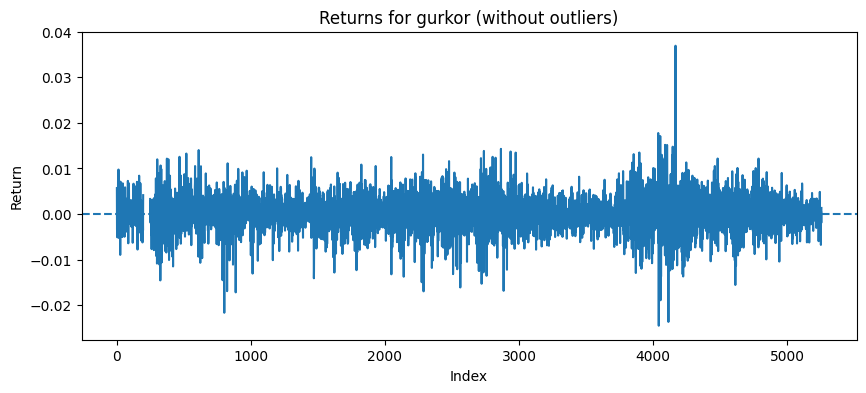

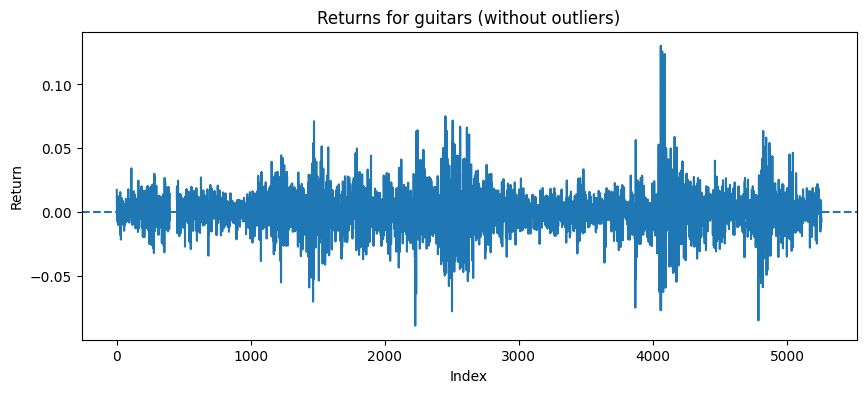

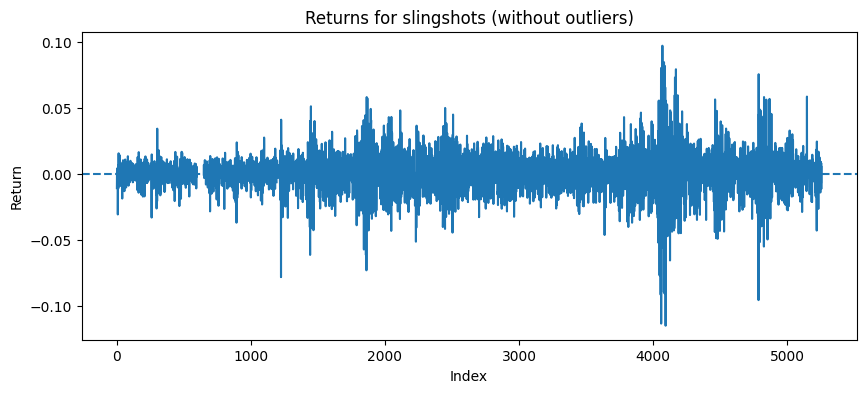

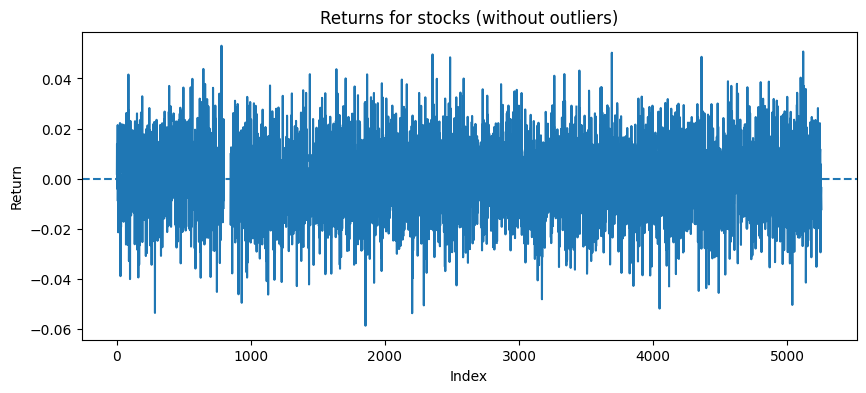

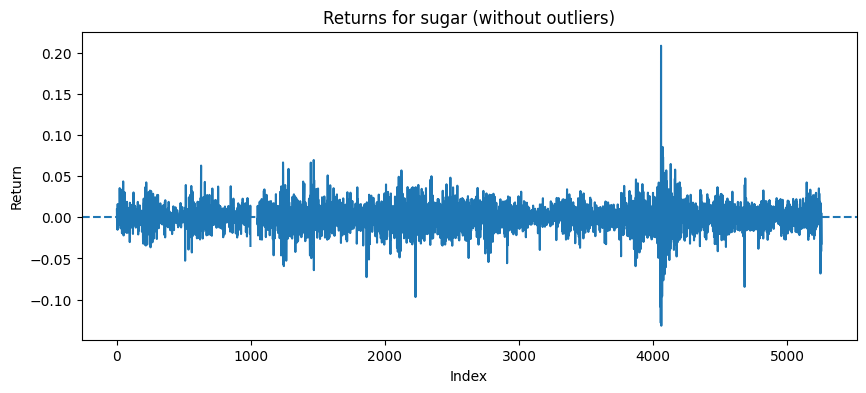

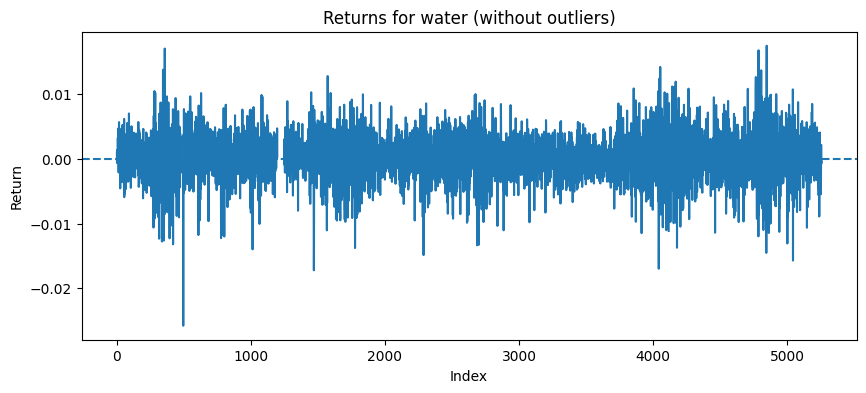

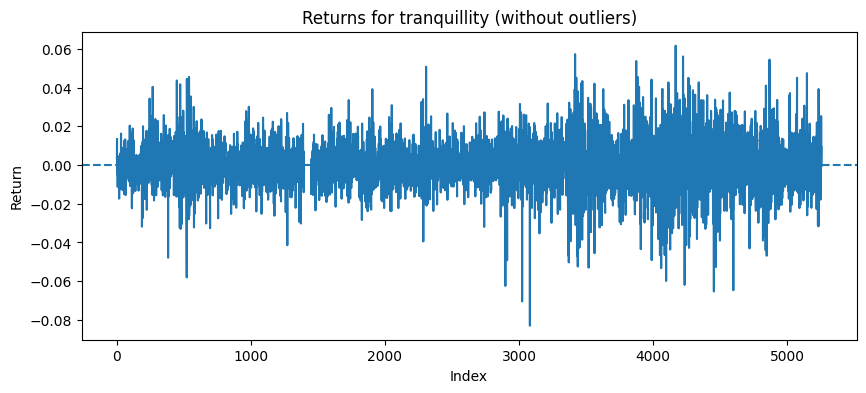

In [50]:

display(returns.describe())
"""
for col in price_col:
    display(df[col].nlargest(10))
    display(df[col].nsmallest(10))
"""

df_clean = df.copy()
df_clean[price_col] = df_clean[price_col].replace(1000, np.nan)
returns_clean = df_clean[price_col].pct_change(fill_method=None)

display(returns_clean.describe())

for col in returns_clean.columns:
    plt.figure(figsize=(10,4))
    plt.plot(returns_clean[col])
    plt.axhline(0, linestyle="--")
    plt.title(f"Returns for {col} (without outliers)")
    plt.xlabel("Index")
    plt.ylabel("Return")
    plt.show()




,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.000000,-0.241020,-0.216559,-0.041302,-0.067944,0.573247,-0.138034
guitars,-0.241020,1.000000,0.526091,0.015796,0.210345,-0.225801,0.223013
slingshots,-0.216559,0.526091,1.000000,0.013045,0.120208,-0.200982,0.187420
stocks,-0.041302,0.015796,0.013045,1.000000,-0.015258,-0.042163,0.009555
sugar,-0.067944,0.210345,0.120208,-0.015258,1.000000,-0.072183,0.125953
water,0.573247,-0.225801,-0.200982,-0.042163,-0.072183,1.000000,-0.158014
tranquillity,-0.138034,0.223013,0.187420,0.009555,0.125953,-0.158014,1.000000


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.00,-0.24,-0.22,-0.04,-0.07,0.57,-0.14
guitars,-0.24,1.00,0.53,0.02,0.21,-0.23,0.22
slingshots,-0.22,0.53,1.00,0.01,0.12,-0.20,0.19
stocks,-0.04,0.02,0.01,1.00,-0.02,-0.04,0.01
sugar,-0.07,0.21,0.12,-0.02,1.00,-0.07,0.13
water,0.57,-0.23,-0.20,-0.04,-0.07,1.00,-0.16
tranquillity,-0.14,0.22,0.19,0.01,0.13,-0.16,1.00


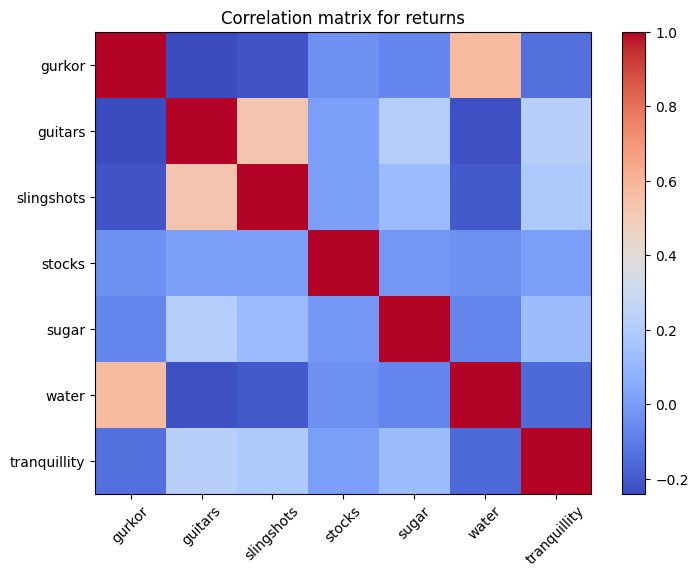

gurkor          255
guitars         255
slingshots      255
stocks          255
sugar           255
water           255
tranquillity    255
dtype: int64


In [53]:
corr = returns_clean.corr()
display(corr)

display(corr.round(2))

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix for returns")
plt.show()
